In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, KBinsDiscretizer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_curve, roc_auc_score
import pickle
import shap
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

To reproduce the results:

1. Unpack and preprocess data inputs ENOE survey and OD survey.
    1. INPUTS: `data/input/enoe_juntado1t23.csv`
    2. OUTPUTS: `data/ouput/enoe_clean_f.csv`

In [2]:
#%run enoe_f.py

2. Perform the grid search. Candidate models are defined in `models_grids_f.py` as dictionaries with model pipelines for different model families.
To perform the grid search run the script `grid_search_f.py`. Note that this step may take a couple of hours to complete.
    1. INPUTS: `models_grids_f.py`, `enoe_clean_f.csv`
    2. OUTPUTS: `repeated_cv_results_f.pkl`, `repeated_best_models_f.csv`

    `repeated_best_models_f.csv` stores metrics for the best model from each algorithm, but it is otherwise not used for further analysis.
    `repeated_cv_results_f.pkl` stores all metrics from the grid search for all candidate models in a pickled data frame.

| Model family|Education preprocessing |Parameter 1   | Parameter 2|
|-------------|------------------------|--------------------------------------------------------------------|-----------------------------|
|LR           |                  scaled| $C \in \{10^x | x = -4 + \frac{8}{9}i,  i \in \{0, 1,\ldots, 9\}\}$|                             |
|LR           |             discretized| $C \in \{10^x | x = -4 + \frac{8}{9}i,  i \in \{0, 1,\ldots, 9\}\}$| $k \in \{5, 6, \ldots, 10\}$|
|LR           |       census categories| $C \in \{10^x | x = -4 + \frac{8}{9}i,  i \in \{0, 1,\ldots, 9\}\}$|                             |
|RF           |                     raw| max_features $\in \{1,\ldots, 9\}$                                 | max_leaf_modes $\in \{5, 7, 10, 25,  50,  65,  85, 100, 250, 500\}$ | 
|RF           |       census categories| max_features $\in \{1,\ldots, 9\}$                                 | max_leaf_modes $\in \{5, 7, 10, 25,  50,  65,  85, 100, 250, 500\}$ | 
|GB           |                     raw| learning_rate $\in \{10^x | x = -1 + \frac{2}{9}i,  i \in \{0, 1,\ldots, 9\}\}$                                | max_leaf_modes $\in \{5, 7, 10, 25,  50,  65,  85, 100, 250, 500\}$ | 
|GB           |       census categories| learning_rate $\in \{10^x | x = -1 + \frac{2}{9}i,  i \in \{0, 1,\ldots, 9\}\}$                                | max_leaf_modes $\in \{5, 7, 10, 25,  50,  65,  85, 100, 250, 500\}$ | 
|SVC          |                  scaled| $C \in \{10^x | x = -4 + \frac{8}{9}i,  i \in \{0, 1,\ldots, 9\}\}$| $\gamma \in \{10^x | x = -4 + \frac{8}{9}i,  i \in \{0, 1,\ldots, 9\}\}$|
|SVC          |       census categories| $C \in \{10^x | x = -4 + \frac{8}{9}i,  i \in \{0, 1,\ldots, 9\}\}$| $\gamma \in \{10^x | x = -4 + \frac{8}{9}i,  i \in \{0, 1,\ldots, 9\}\}$|
|KNN          |       census categories| $K \in \{1, \ldots, 10 \}$    |

In [3]:
#%run grid_search_f.py

## Load grid search results

In [4]:
cv_results = pd.read_pickle('./data/output/repeated_cv_results_f.pkl')

cv_results = cv_results.rename(columns={c: c.split('param_')[-1] for c in cv_results.columns if c.startswith('param_')})

print(f'Total models compared: {int(cv_results.shape[0]/10)}')

Total models compared: 774


In [5]:
cv_results.model.nunique()

10

## Extracting best models for each algorithm for each outer fold

In [6]:
from enoe_f import load_enoe

enoe = load_enoe()

y = enoe['informal']
X = enoe.drop(columns='informal')

In [7]:
top_models = cv_results.loc[cv_results.groupby(['fold', 'model']).mean_test_score.idxmax()].set_index(['fold', 'model']).sort_index()

In [8]:
%%time
from models_grids_f import models_LR, models_RF, models_GB, models_SVC, models_KNN

models = models_LR | models_RF | models_GB | models_SVC | models_KNN

cv_outer = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_outer_idxs = list(cv_outer.split(X, y))

# Retrain models on same outer folds

scores = defaultdict(list)
rocs = defaultdict(list)

mean_fpr = np.linspace(0, 1, 100)


for (fold, model_key), row in top_models.iterrows():
    train_index, test_index = cv_outer_idxs[fold]
    X_train, y_train = X.iloc[train_index], y.iloc[train_index]
    X_test, y_test = X.iloc[test_index], y.iloc[test_index]

    params = row.params
    if 'SVC' in model_key:
        params['classifier__probability'] = True
    model = models[model_key]['model'].set_params(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    score = balanced_accuracy_score(y_test, y_pred)
    scores[model_key].append((fold, score))
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    
    auc = roc_auc_score(y_test, y_prob)
    rocs[model_key].append({'fold': fold, 'score': score, 'tpr': interp_tpr, 'auc': auc})
#pd.Series({'mean_balanced_accuracy': np.mean(scores), 'std_balanced_accuracy': np.std(scores), 'mean_accuracy': np.mean(acc), 'std_accuracy': np.std(accs)})

CPU times: total: 7min 27s
Wall time: 7min 19s


In [9]:
scores_roc = {} 
for key, vals in rocs.items():
    scores_roc[key] = {'score': [], 'tpr': [], 'auc': []} 
    for d in vals:
        for k in scores_roc[key].keys():
            scores_roc[key][k].append(d[k])
    keys = list(scores_roc[key].keys())
    for k in keys:
        scores_roc[key][k] = np.array(scores_roc[key][k])
        scores_roc[key][f"{k}_mean"] = scores_roc[key][k].mean(axis=0)
        scores_roc[key][f"{k}_std"] = scores_roc[key][k].std(axis=0)

In [10]:
roc_df = pd.DataFrame(scores_roc).T
roc_df

,score,tpr,auc,score_mean,score_std,tpr_mean,tpr_std,auc_mean,auc_std
GB_ed_cnss,"[0.7631229003359463, 0.7492651175811871, 0.733...","[[0.0, 0.2295986177565125, 0.27960526315789475...","[0.8350188969764838, 0.823496990481523, 0.8206...",0.738261,0.013778,"[0.0, 0.2051608779298982, 0.25559427653291644,...","[0.0, 0.04303313978977843, 0.04616927893032586...",0.821011,0.009403
GB_ed_num,"[0.7569288913773796, 0.7499650055991041, 0.735...","[[0.0, 0.20394736842105263, 0.3125, 0.31907894...","[0.8361343435050392, 0.8216029185330347, 0.824...",0.741734,0.011839,"[0.0, 0.1933656852527358, 0.2694057234670836, ...","[0.0, 0.045568835246552246, 0.0310616179267259...",0.823545,0.009564
KNN_ed_cnss,"[0.7066769316909294, 0.7252939529675252, 0.712...","[[0.0, 0.07497489515033376, 0.1221720125228897...","[0.7836121220604704, 0.7841589095744681, 0.784...",0.706403,0.013309,"[0.0, 0.10568495957782913, 0.1647410697390465,...","[0.0, 0.030202371036765246, 0.0400412757580593...",0.780646,0.009013
LR_ed_cnss,"[0.75489921612542, 0.7538143896976484, 0.73662...","[[0.0, 0.19407894736842105, 0.271697235513025,...","[0.8308064459686451, 0.8226614991601344, 0.810...",0.736682,0.013285,"[0.0, 0.20652466562445718, 0.26172331048894365...","[0.0, 0.03749853221755874, 0.02194833521317370...",0.81693,0.009426
LR_ed_dsc,"[0.7574888017917133, 0.7508398656215005, 0.735...","[[0.0, 0.18092105263157895, 0.2203947368421052...","[0.8335447578387457, 0.8200019246920492, 0.811...",0.736317,0.015671,"[0.0, 0.1692776185513288, 0.23514417231196805,...","[0.0, 0.05109306496014283, 0.03548905722380867...",0.816216,0.009803
LR_ed_scl,"[0.7379969204927211, 0.7336926091825308, 0.712...","[[0.0, 0.2565789473684211, 0.3059210526315789,...","[0.8284618211086228, 0.8159731942889137, 0.799...",0.728257,0.010113,"[0.0, 0.17882794858433212, 0.22033285565398647...","[0.0, 0.052395679988673886, 0.0417572382723077...",0.807475,0.010238
RF_ed_cnss,"[0.7516797312430011, 0.7350223964165734, 0.724...","[[0.0, 0.23026315789473684, 0.2828947368421052...","[0.8296472564389697, 0.8104047102463605, 0.819...",0.735497,0.011432,"[0.0, 0.20281584079460577, 0.2820529202043011,...","[0.0, 0.048321366997456275, 0.0490193688970220...",0.819881,0.010014
RF_ed_num,"[0.7671822508398656, 0.7369820828667413, 0.744...","[[0.0, 0.18092105263157895, 0.2861842105263157...","[0.8376740971444567, 0.8153739151735723, 0.824...",0.743656,0.011834,"[0.0, 0.19037258989056802, 0.2736918099704707,...","[0.0, 0.04244599312700389, 0.04230077892523929...",0.822708,0.011737
SVC_ed_cnss,"[0.7529395296752519, 0.744400895856663, 0.7396...","[[0.0, 0.18092105263157895, 0.2335526315789473...","[0.8287680221164613, 0.8251810960246362, 0.812...",0.738616,0.009138,"[0.0, 0.19921572201079757, 0.2519910543685947,...","[0.0, 0.04463496875576188, 0.03961268117890160...",0.817119,0.008827
SVC_ed_scl,"[0.7724314109742442, 0.7605333146696529, 0.732...","[[0.0, 0.16776315789473684, 0.2203947368421052...","[0.8297128709406495, 0.828649916013438, 0.8082...",0.743285,0.01579,"[0.0, 0.1844493659892305, 0.2298864425916276, ...","[0.0, 0.04278379926857065, 0.03748540600679284...",0.818622,0.009849


In [11]:
linestyles = [
     (0, (1, 1)),
     (5, (10, 3)),
    #@(0, (5, 10)),
     (0, (5, 5)),
     (0, (5, 1)),

     (0, (3, 10, 1, 10)),
     (0, (3, 5, 1, 5)),
     (0, (3, 1, 1, 1)),

     (0, (3, 5, 1, 5, 1, 5)),
     (0, (3, 10, 1, 10, 1, 10)),
     (0, (3, 1, 1, 1, 1, 1))]

In [12]:
model_names = {
    'GB_ed_cnss': "GBT (census)",
    'GB_ed_num': "GBT",
    'KNN_ed_cnss': "KNN",
    'LR_ed_cnss': "LR (census)",
    'LR_ed_dsc': "LR (binning)",
    'LR_ed_scl': "LR (scaled)",
    'RF_ed_cnss': "RF (census)",
    'RF_ed_num': "RF",
    'SVC_ed_cnss': "SVM (census)", 
    'SVC_ed_scl': "SVM (scaled)"
}

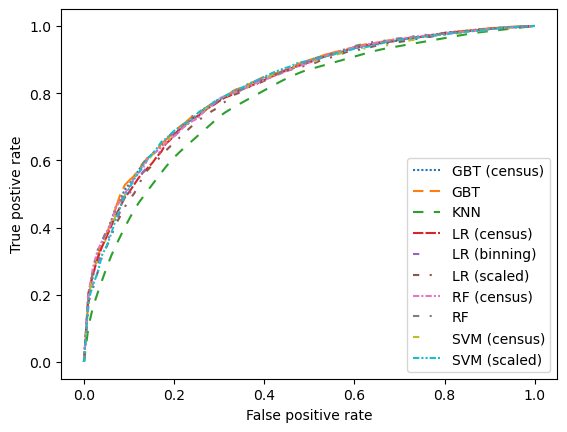

In [13]:
for i, (model, row) in enumerate(roc_df.iterrows()):
    plt.plot(
        mean_fpr,
        row.tpr_mean,
        ls=linestyles[i],
        label=(
            f"{model_names[model]}"
            #f" AUC={row.auc_mean:0.4}"
            #f"$\pm$ {row.auc_std:0.4}"
        )
    )
plt.legend()
plt.xlabel("False positive rate")
plt.ylabel("True postive rate");
plt.savefig("ROC.png")

In [14]:
roc_df.index

Index(['GB_ed_cnss', 'GB_ed_num', 'KNN_ed_cnss', 'LR_ed_cnss', 'LR_ed_dsc',
       'LR_ed_scl', 'RF_ed_cnss', 'RF_ed_num', 'SVC_ed_cnss', 'SVC_ed_scl'],
      dtype='object')

In [15]:
for key, vals in scores.items():
    scores[key] = np.array(sorted(scores[key], key=lambda t: t[0]))[:, 1]

In [16]:
scores_cv_outer = pd.Series(scores).apply(pd.Series).agg(['mean', 'std'], axis=1).sort_values('mean', ascending=False)

## Comparison of classifiers one outer fold

In [17]:
import baycomp

In [18]:
scores_cv_outer = scores_cv_outer.assign(p_l=0.0, p_rope=0.0, p_r=0.0)

In [19]:
best_model = scores_cv_outer['mean'].idxmax()
best_scores = scores[best_model]
for model_key, model_scores in scores.items():
    pl, prope, pr = baycomp.two_on_single(model_scores, best_scores, rope=0.01, runs=1)
    scores_cv_outer.loc[model_key, ['p_l', 'p_rope', 'p_r']] = pl, prope, pr

In [20]:
round(scores_cv_outer, 4)

,mean,std,p_l,p_rope,p_r
RF_ed_num,0.7437,0.0125,0.0000,1.0000,0.0000
SVC_ed_scl,0.7433,0.0166,0.0503,0.8880,0.0618
GB_ed_num,0.7417,0.0125,0.0064,0.9609,0.0327
SVC_ed_cnss,0.7386,0.0096,0.0010,0.9031,0.0959
GB_ed_cnss,0.7383,0.0145,0.0010,0.8837,0.1153
LR_ed_cnss,0.7367,0.0140,0.0076,0.6888,0.3036
LR_ed_dsc,0.7363,0.0165,0.0118,0.6451,0.3431
RF_ed_cnss,0.7355,0.0121,0.0003,0.6895,0.3101
LR_ed_scl,0.7283,0.0107,0.0001,0.1277,0.8721
KNN_ed_cnss,0.7064,0.0140,0.0001,0.0026,0.9973


## Retrain best model (GB)

In [21]:
# Best model: GB_ed_num (Mean close to RF_ed_num and SVC_ed_scl, prope within 0.9, higher AUC). So, we keep the same model as for Monterrey.  
# But hyperparameters need to be selected using full training set

In [22]:
model = models['GB_ed_num']['model']
param_grid = models['GB_ed_num']['params']

In [23]:
cv_inner = StratifiedKFold(n_splits=5)

search = GridSearchCV(
    model, param_grid,
    cv=cv_inner,
    n_jobs=8,
    scoring='balanced_accuracy',
    verbose=1
)
search.fit(X, y)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('od_encoder',
                                                                         OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                        unknown_value=-1),
                                                                         ['genero',
                                                                          'ocupacion',
                                                                          'sector',
                                                                          'escolaridad',
                                                                          'municipio',
                                                                          'estado_civil',
                                                                          'parentesco',
                                                                          'tamano_viv_cat']),
                                                                        ('passthrough'...
                                                                       learning_rate=np.float64(0.046415888336127774),
                                                                       max_iter=1000,
                                                                       max_leaf_nodes=7,
                                                                       random_state=0))]),
             n_jobs=8,
             param_grid={'classifier__learning_rate': array([0.01      , 0.01668101, 0.02782559, 0.04641589, 0.07742637,
       0.12915497, 0.21544347, 0.35938137, 0.59948425, 1.        ]),
                         'classifier__max_leaf_nodes': [5, 7, 10, 25, 50, 65,
                                                        85, 100, 250, 500]},
             scoring='balanced_accuracy', verbose=1)

In [24]:
search.best_params_

{'classifier__learning_rate': np.float64(0.21544346900318834),
 'classifier__max_leaf_nodes': 5}

In [25]:
gb1_best_params = search.best_params_

In [26]:
model = search.best_estimator_

In [27]:
X_transformed = model['preprocessor'].transform(X)
X_transformed = pd.DataFrame(X_transformed, columns=[name.split('__')[1] for name in model['preprocessor'].get_feature_names_out()])

In [28]:
explainer_1 = shap.TreeExplainer(model['classifier'], data=X_transformed, model_output='probability')
shap_values_1 = explainer_1.shap_values(X_transformed, y)
exp = explainer_1(X_transformed, y)

Background dataset has 6792 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6792 when initializing the masker.


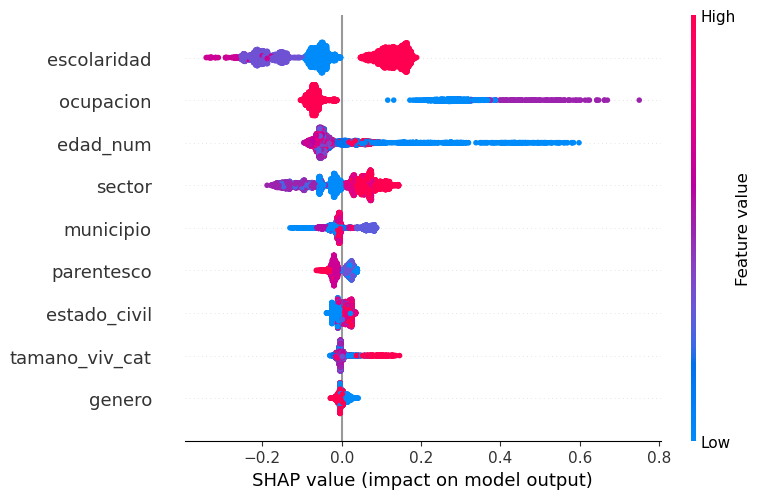

In [29]:
shap.summary_plot(shap_values_1, X_transformed)

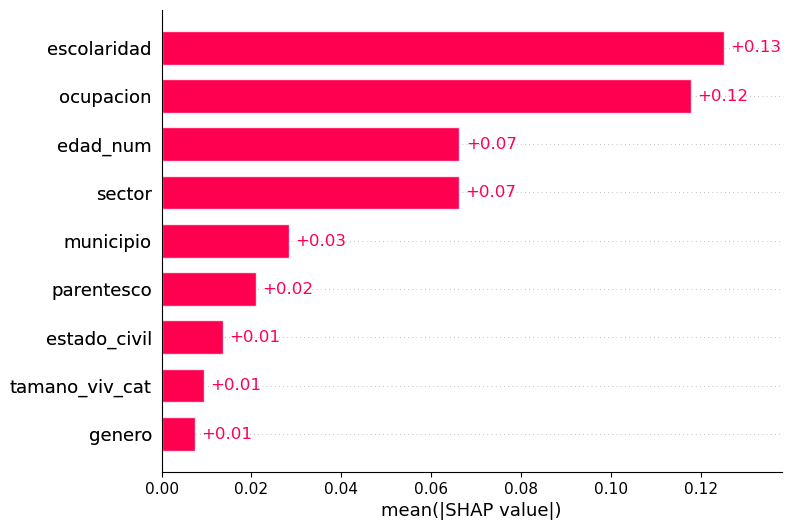

In [30]:
shap.plots.bar(exp)

In [31]:
X.ocupacion.value_counts()

ocupacion
trabajador       5390
independiente    1235
otro              167
Name: count, dtype: int64

In [32]:
X_transformed.shape

(6792, 9)

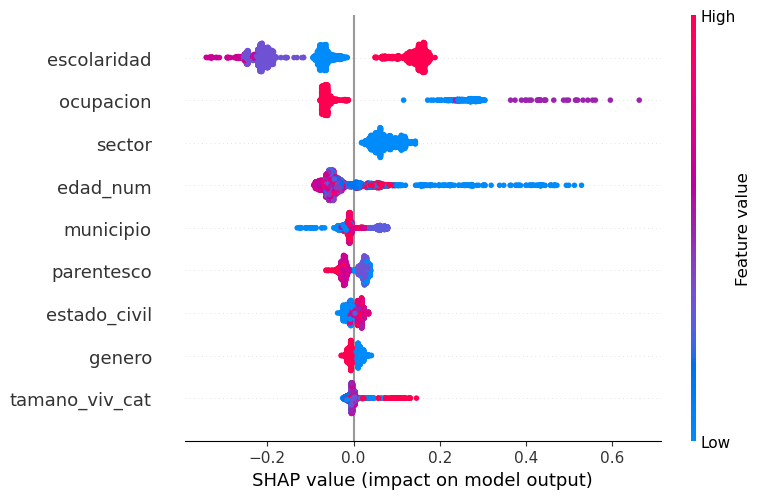

In [33]:
mask = (X_transformed.sector == 4)

shap.summary_plot(shap_values_1[mask], X_transformed[mask])

In [34]:
mask = np.logical_and((X_transformed.sector == 4), (X_transformed.genero == 1))
shap_values_1[mask][:, 0].mean()

np.float64(-0.00894515830560885)

In [35]:
mask = np.logical_and((X_transformed.sector == 4), (X_transformed.genero == 0))
shap_values_1[mask][:, 0].mean()

np.float64(0.01442112097295873)

In [36]:
model['preprocessor'].transformers_[0][1].categories_

[array(['F', 'H'], dtype=object),
 array(['independiente', 'otro', 'trabajador'], dtype=object),
 array(['Comercio', 'Gobierno', 'Industria_manufacturera', 'Otro',
        'Servicios'], dtype=object),
 array(['Carrera_tecnica_o_preparatoria', 'Licenciatura', 'Postgrado',
        'Primaria_o_Secundaria', 'Sin_Instruccion'], dtype=object),
 array(['el_salto', 'guadalajara', 'ixtlahuacan_membrillos', 'otro',
        'tala', 'tlajomulco', 'tlaquepaque', 'tonala', 'zapopan'],
       dtype=object),
 array(['casado', 'divorciado', 'separado', 'soltero', 'union_libre',
        'viudo'], dtype=object),
 array(['conyuge', 'hijo', 'jefe_del_hogar', 'otro_parentesco',
        'sin_parentesco'], dtype=object),
 array(['1', '10_y_mas', '2', '3', '4', '5', '6', '7', '8', '9'],
       dtype=object)]

## Load OD survey

In [37]:
model['preprocessor'].feature_names_in_

array(['tamano_viv', 'genero', 'ocupacion', 'edad_num', 'edad_cat',
       'sector', 'escolaridad', 'municipio', 'estado_civil', 'parentesco',
       'tamano_viv_cat'], dtype=object)

In [38]:
X

,tamano_viv,genero,ocupacion,edad_num,edad_cat,sector,escolaridad,municipio,estado_civil,parentesco,tamano_viv_cat
0,3,H,trabajador,42,"[25, 50)",Otro,Licenciatura,otro,casado,jefe_del_hogar,3
1,3,F,independiente,40,"[25, 50)",Servicios,Carrera_tecnica_o_preparatoria,otro,casado,conyuge,3
2,3,F,trabajador,32,"[25, 50)",Servicios,Licenciatura,otro,soltero,otro_parentesco,3
3,2,F,trabajador,36,"[25, 50)",Comercio,Licenciatura,otro,soltero,jefe_del_hogar,2
4,2,F,trabajador,35,"[25, 50)",Otro,Licenciatura,otro,soltero,sin_parentesco,2
...,...,...,...,...,...,...,...,...,...,...,...
6787,3,H,independiente,52,"[50, 60)",Otro,Primaria_o_Secundaria,otro,union_libre,jefe_del_hogar,3
6788,3,H,independiente,34,"[25, 50)",Servicios,Carrera_tecnica_o_preparatoria,otro,union_libre,jefe_del_hogar,3
6789,4,H,trabajador,61,"[60, 65)",Otro,Primaria_o_Secundaria,otro,casado,jefe_del_hogar,4
6790,2,F,independiente,47,"[25, 50)",Servicios,Primaria_o_Secundaria,otro,divorciado,jefe_del_hogar,2


In [39]:
# Built by EODGDL_ProcessForModel.ipynb
od_final = pd.read_csv('od_processed.csv')
od_final.head()

,genero,ocupacion,edad_num,edad_cat,sector,escolaridad,municipio,estado_civil,parentesco,tamano_viv_cat,FE
0,H,trabajador,51,"[50, 60)",Servicios,Postgrado,tlajomulco,casado,jefe_del_hogar,5,51
1,H,trabajador,68,"[65, 131)",Servicios,Primaria_o_Secundaria,guadalajara,soltero,jefe_del_hogar,3,249
2,H,trabajador,61,"[60, 65)",Servicios,Carrera_tecnica_o_preparatoria,guadalajara,soltero,otro_parentesco,3,249
3,H,trabajador,76,"[65, 131)",Servicios,Licenciatura,guadalajara,casado,conyuge,3,249
4,F,independiente,63,"[60, 65)",Comercio,Primaria_o_Secundaria,guadalajara,casado,conyuge,3,249


In [40]:
informal_od = model.predict(od_final)
informal_proba = model.predict_proba(od_final)

### *Comparing against ENOE (Jalisco)*

In [41]:
print(f'Proportion of informal trips in ENOE: {enoe.informal.sum()/enoe.shape[0]:0.4f}')
print(f'Proportion of estimated informal trips in OD (no EF): {informal_od.sum()/od_final.shape[0]:0.4f}')
print(f'Expected value informal trips in OD (no EF): {informal_proba[:, 1].sum()/od_final.shape[0]:0.4f}')
print(f'Proportion of estimated informal trips in OD (with EF): {(od_final.FE.values * informal_od).sum()/od_final.FE.sum():0.4f}')
print(f'Expected value informal trips in OD (with EF): {(od_final.FE.values * informal_proba[:, 1]).sum()/od_final.FE.sum():0.4f}')

Proportion of informal trips in ENOE: 0.4470
Proportion of estimated informal trips in OD (no EF): 0.2201
Expected value informal trips in OD (no EF): 0.3401
Proportion of estimated informal trips in OD (with EF): 0.2105
Expected value informal trips in OD (with EF): 0.3342


In [42]:
# Proportion by sector
od_pred = od_final.assign(informal=informal_od, informal_proba=informal_proba[:, 1])

In [43]:
od_pred.head()

,genero,ocupacion,edad_num,edad_cat,sector,escolaridad,municipio,estado_civil,parentesco,tamano_viv_cat,FE,informal,informal_proba
0,H,trabajador,51,"[50, 60)",Servicios,Postgrado,tlajomulco,casado,jefe_del_hogar,5,51,0,0.070876
1,H,trabajador,68,"[65, 131)",Servicios,Primaria_o_Secundaria,guadalajara,soltero,jefe_del_hogar,3,249,1,0.595417
2,H,trabajador,61,"[60, 65)",Servicios,Carrera_tecnica_o_preparatoria,guadalajara,soltero,otro_parentesco,3,249,0,0.295497
3,H,trabajador,76,"[65, 131)",Servicios,Licenciatura,guadalajara,casado,conyuge,3,249,0,0.256624
4,F,independiente,63,"[60, 65)",Comercio,Primaria_o_Secundaria,guadalajara,casado,conyuge,3,249,1,0.878062


In [44]:
# Fraction of informal distributed by sector
inf_by_sect = pd.concat(
    [
        (od_pred.groupby('sector').informal.sum()/od_pred.informal.sum()*100).rename('OD'),
        (od_pred.groupby('sector').informal_proba.sum()/od_pred.informal_proba.sum()*100).rename('OD Expected'),
        (enoe.groupby('sector').informal.sum()/enoe.informal.sum()*100).rename('ENOE')
    ],
    axis=1
)
inf_by_sect

,OD,OD Expected,ENOE
sector,,,
Comercio,32.821205,27.892227,24.440053
Gobierno,0.101300,0.881115,0.625823
Industria_manufacturera,4.406551,11.392127,11.660079
Otro,14.789802,27.424127,25.691700
Servicios,47.881141,32.410403,37.582345


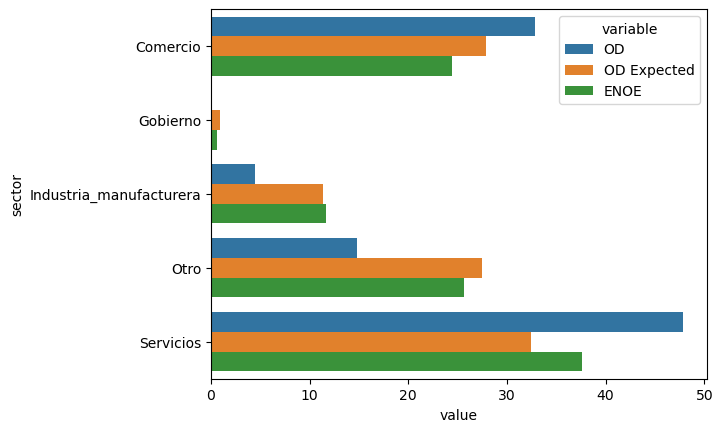

In [45]:
sns.barplot(inf_by_sect.reset_index().melt(id_vars=['sector']), y='sector', x='value', hue='variable');

In [46]:
# Fraction of informal within each sector
inf_within_sect = pd.concat(
    [
        (od_pred.groupby('sector').informal.agg(['sum', 'size']).pipe(lambda df: df['sum']/df['size']*100)).rename('OD'),
        (od_pred.groupby('sector').informal_proba.agg(['sum', 'size']).pipe(lambda df: df['sum']/df['size']*100)).rename('OD Expected'),
        (enoe.groupby('sector').informal.agg(['sum', 'size']).pipe(lambda df: df['sum']/df['size']*100)).rename('ENOE')
    ],
    axis=1
)
inf_within_sect

,OD,OD Expected,ENOE
sector,,,
Comercio,33.128834,43.502523,49.009247
Gobierno,0.940439,12.639604,9.004739
Industria_manufacturera,5.735003,22.909698,26.940639
Otro,9.236609,26.464435,58.252427
Servicios,44.507219,46.551108,47.265949


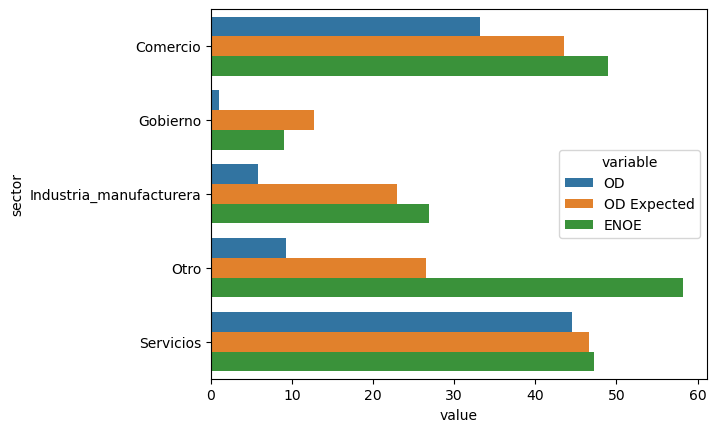

In [47]:
sns.barplot(inf_within_sect.reset_index().melt(id_vars=['sector']), y='sector', x='value', hue='variable');

### *Comparing against ENOE (Zona Metropolitana de Guadalajara)*

Only municipalities other than 'Otro' for both ENOE and OD

In [48]:
#ENOE
enoe_zmg = enoe.query("municipio != 'otro'").reset_index(drop=True)

#OD
zmg_mask = (od_final.municipio != 'otro').values

od_final_zmg = od_final[zmg_mask]
informal_od_zmg = informal_od[zmg_mask]
informal_proba_zmg = informal_proba[zmg_mask]

In [49]:
print(f'Proportion of informal trips in ENOE (ZMG): {enoe_zmg.informal.sum()/enoe_zmg.shape[0]:0.4f}')
print(f'Proportion of estimated informal trips in OD (no EF): {informal_od_zmg.sum()/od_final_zmg.shape[0]:0.4f}')
print(f'Expected value informal trips in OD (no EF): {informal_proba_zmg[:, 1].sum()/od_final_zmg.shape[0]:0.4f}')
print(f'Proportion of estimated informal trips in OD (with EF): {(od_final_zmg.FE.values * informal_od_zmg).sum()/od_final_zmg.FE.sum():0.4f}')
print(f'Expected value informal trips in OD (with EF): {(od_final_zmg.FE.values * informal_proba_zmg[:, 1]).sum()/od_final_zmg.FE.sum():0.4f}')

Proportion of informal trips in ENOE (ZMG): 0.3970
Proportion of estimated informal trips in OD (no EF): 0.2127
Expected value informal trips in OD (no EF): 0.3331
Proportion of estimated informal trips in OD (with EF): 0.2090
Expected value informal trips in OD (with EF): 0.3328


In [50]:
# Proportion by sector
od_pred_zmg = od_final_zmg.assign(informal=informal_od_zmg, informal_proba=informal_proba_zmg[:, 1])

In [51]:
od_pred_zmg.head()

,genero,ocupacion,edad_num,edad_cat,sector,escolaridad,municipio,estado_civil,parentesco,tamano_viv_cat,FE,informal,informal_proba
0,H,trabajador,51,"[50, 60)",Servicios,Postgrado,tlajomulco,casado,jefe_del_hogar,5,51,0,0.070876
1,H,trabajador,68,"[65, 131)",Servicios,Primaria_o_Secundaria,guadalajara,soltero,jefe_del_hogar,3,249,1,0.595417
2,H,trabajador,61,"[60, 65)",Servicios,Carrera_tecnica_o_preparatoria,guadalajara,soltero,otro_parentesco,3,249,0,0.295497
3,H,trabajador,76,"[65, 131)",Servicios,Licenciatura,guadalajara,casado,conyuge,3,249,0,0.256624
4,F,independiente,63,"[60, 65)",Comercio,Primaria_o_Secundaria,guadalajara,casado,conyuge,3,249,1,0.878062


In [52]:
# Fraction of informal distributed by sector
inf_by_sect_zmg = pd.concat(
    [
        (od_pred_zmg.groupby('sector').informal.sum()/od_pred_zmg.informal.sum()*100).rename('OD'),
        (od_pred_zmg.groupby('sector').informal_proba.sum()/od_pred_zmg.informal_proba.sum()*100).rename('OD Expected'),
        (enoe_zmg.groupby('sector').informal.sum()/enoe_zmg.informal.sum()*100).rename('ENOE')
    ],
    axis=1
)
inf_by_sect_zmg

,OD,OD Expected,ENOE
sector,,,
Comercio,31.981982,27.478101,28.257687
Gobierno,0.112613,0.910025,0.390434
Industria_manufacturera,4.072823,11.171043,12.640312
Otro,14.921171,27.457808,16.251830
Servicios,48.911411,32.983022,42.459736


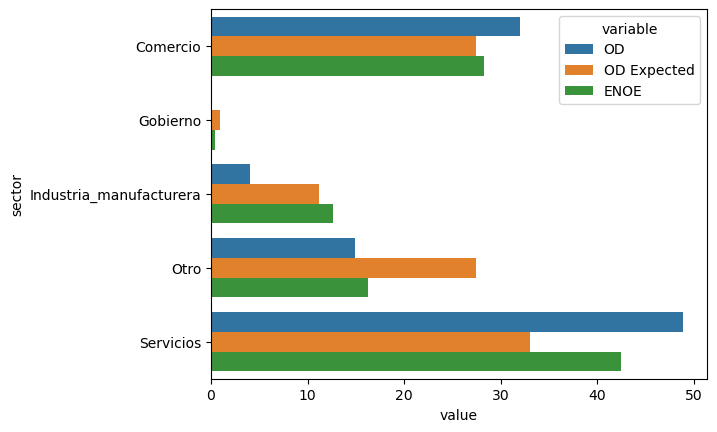

In [53]:
sns.barplot(inf_by_sect_zmg.reset_index().melt(id_vars=['sector']), y='sector', x='value', hue='variable');

In [54]:
# Fraction of informal within each sector
inf_within_sect_zmg = pd.concat(
    [
        (od_pred_zmg.groupby('sector').informal.agg(['sum', 'size']).pipe(lambda df: df['sum']/df['size']*100)).rename('OD'),
        (od_pred_zmg.groupby('sector').informal_proba.agg(['sum', 'size']).pipe(lambda df: df['sum']/df['size']*100)).rename('OD Expected'),
        (enoe_zmg.groupby('sector').informal.agg(['sum', 'size']).pipe(lambda df: df['sum']/df['size']*100)).rename('ENOE')
    ],
    axis=1
)
inf_within_sect_zmg

,OD,OD Expected,ENOE
sector,,,
Comercio,31.602374,42.528901,46.996753
Gobierno,0.990099,12.532220,4.968944
Industria_manufacturera,5.127599,22.029031,23.524069
Otro,9.022812,26.006865,46.121884
Servicios,43.346640,45.784535,44.730077


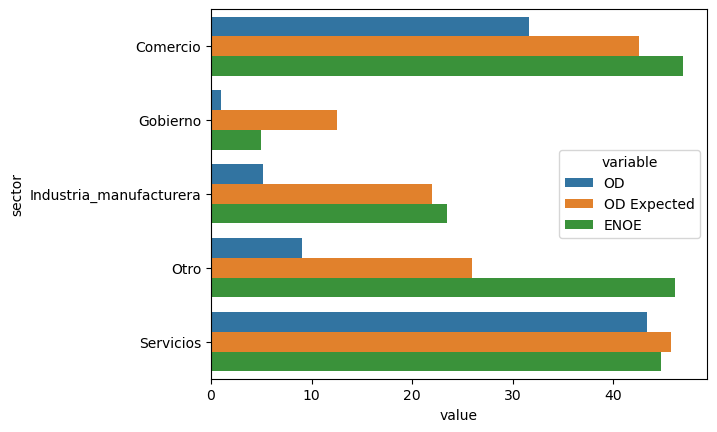

In [55]:
sns.barplot(inf_within_sect_zmg.reset_index().melt(id_vars=['sector']), y='sector', x='value', hue='variable');

## Second model, using GB, tune parameters with nested cross validation

NOTE: This part comes from the Monterrey model and hasn't been updated. In Monterrey, informal workers in "Other" were reclassified into Comercio and Construcción.
However, this should be analyzed specifically for the Guadalajara case. In Monterrey, all workers within "Other" were first classified as informal, which does not happen in the current version of the Guadalajara model. Also, right now the comparison for "Other" between the model and ENOE shows similar numbers by sectors (this did not happen in Monterrey, since the numbers were very different between those two). In addition, the OD survey for Guadalajara has fewer economic sectors and does not identify "construcción". Therefore, this implementation must be discussed, and the code below changed/updated accordingly.

In [39]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_validate, GridSearchCV, RepeatedStratifiedKFold

In [40]:
enoe_2 = enoe.query('sector.isin(["Comercio", "Construcción"])')
y2 = enoe_2['sector'].values
X2 = enoe_2.drop(columns=['informal', 'sector'])

In [41]:
model_2 = Pipeline([
            (
                'preprocessor',
                ColumnTransformer([
                    (
                        "od_encoder",
                        OrdinalEncoder(
                            handle_unknown='use_encoded_value',
                            unknown_value=-1
                        ),
                        ['genero', 'escolaridad', 'municipio', 'ocupacion', 'estado_civil', 'parentesco', 'tamano_viv_cat']
                    ),
                    ('passthrough', 'passthrough', ['edad_num']), 
                ])
            ),
            (
                'classifier',
                HistGradientBoostingClassifier(
                    max_iter=1000,
                    early_stopping=True,
                    random_state=0
                )
            )
        ])

param_grid = {
    'classifier__learning_rate': np.geomspace(0.01, 1, 10),
    'classifier__max_leaf_nodes': [5, 7, 10, 25, 50, 65, 85, 100, 250, 500],
}

In [42]:
%%time
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_outer = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(model_2, param_grid, scoring='balanced_accuracy', cv=cv_inner, n_jobs=8, verbose=1)
cv_results = cross_validate(search, X2, y2, scoring=['balanced_accuracy', 'accuracy'], cv=cv_outer, return_estimator=True, verbose=1)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: total: 44.8 s
Wall time: 5min 34s


In [43]:
cv_results = pd.DataFrame(cv_results)
cv_results

,fit_time,score_time,estimator,test_balanced_accuracy,test_accuracy
0,36.199381,0.039008,"GridSearchCV(cv=StratifiedKFold(n_splits=5, ra...",0.701237,0.784314
1,36.000344,0.027033,"GridSearchCV(cv=StratifiedKFold(n_splits=5, ra...",0.681680,0.799020
2,32.140085,0.024273,"GridSearchCV(cv=StratifiedKFold(n_splits=5, ra...",0.630061,0.759804
3,29.658602,0.024976,"GridSearchCV(cv=StratifiedKFold(n_splits=5, ra...",0.649545,0.779412
4,30.779272,0.019633,"GridSearchCV(cv=StratifiedKFold(n_splits=5, ra...",0.713310,0.799020
5,35.991276,0.033564,"GridSearchCV(cv=StratifiedKFold(n_splits=5, ra...",0.706635,0.798030
6,37.201446,0.021970,"GridSearchCV(cv=StratifiedKFold(n_splits=5, ra...",0.700968,0.817734
7,28.606741,0.019881,"GridSearchCV(cv=StratifiedKFold(n_splits=5, ra...",0.574694,0.714286
8,33.066750,0.022155,"GridSearchCV(cv=StratifiedKFold(n_splits=5, ra...",0.657922,0.753695
9,34.916527,0.031701,"GridSearchCV(cv=StratifiedKFold(n_splits=5, ra...",0.629712,0.758621


In [44]:
cv_results.agg({'test_balanced_accuracy': ['mean', 'std'], 'test_accuracy': ['mean', 'std']})

,test_balanced_accuracy,test_accuracy
mean,0.664576,0.776393
std,0.044548,0.030252


In [45]:
pd.DataFrame([estimator.best_params_ for estimator in cv_results.estimator])

,classifier__learning_rate,classifier__max_leaf_nodes
0,0.359381,25
1,0.215443,7
2,0.599484,5
3,0.215443,10
4,0.359381,5
5,0.599484,50
6,0.599484,5
7,0.359381,50
8,0.215443,65
9,0.359381,5


In [46]:
model_2.set_params(**gb1_best_params)
model_2.fit(X2, y2)
model_2.score(X2, y2)

0.8049140049140049

In [87]:
od_final_2 = od_final.query("sector == 'Otro'")
od_final_2

,genero,ocupacion,edad_num,edad_cat,sector,escolaridad,municipio,FE
31,H,otro,14,12-14,Otro,Carrera técnica o preparatoria,santiago,23.945540
34,F,otro,24,18-24,Otro,Primaria o Secundaria,santiago,36.876132
125,F,otro,32,25-49,Otro,Primaria o Secundaria,santiago,23.945540
133,F,otro,55,50-59,Otro,Primaria o Secundaria,santiago,28.734648
137,F,otro,65,65-130,Otro,Primaria o Secundaria,santiago,28.734648
...,...,...,...,...,...,...,...,...
20723,F,otro,42,25-49,Otro,Carrera técnica o preparatoria,san_pedro,109.531927
20725,H,otro,62,60-64,Otro,Carrera técnica o preparatoria,san_pedro,109.531927
20726,H,otro,79,65-130,Otro,Carrera técnica o preparatoria,san_pedro,109.531927
20727,F,otro,68,65-130,Otro,Carrera técnica o preparatoria,san_pedro,109.531927


In [88]:
od_pred = od_pred.assign(sector_2=pd.Series(model_2.predict(od_final_2), index=od_final_2.index).reindex(od_pred.index).pipe(lambda s: s.mask(s.isna(), od_pred.sector)))

In [89]:
od_pred.to_csv('od_pred.csv', index=False)

In [47]:
X_transformed_2 = model_2['preprocessor'].transform(X2)
X_transformed_2 = pd.DataFrame(X_transformed_2, columns=[name.split('__')[1] for name in model_2['preprocessor'].get_feature_names_out()])
explainer_2 = shap.TreeExplainer(model_2['classifier'], data=X_transformed_2, model_output='probability')
#shap_values_2 = explainer_2.shap_values(X_transformed_2, y2)
#exp_2 = explainer_2(X_transformed_2, y2)
#shap.plots.bar(exp_2)

Background dataset has 2035 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2035 when initializing the masker.


In [48]:
X_transformed_2

,genero,escolaridad,municipio,ocupacion,estado_civil,parentesco,tamano_viv_cat,edad_num
0,1.0,1.0,3.0,2.0,0.0,2.0,3.0,42.0
1,0.0,1.0,3.0,2.0,3.0,2.0,2.0,36.0
2,0.0,1.0,3.0,2.0,3.0,4.0,2.0,35.0
3,1.0,3.0,3.0,2.0,1.0,2.0,5.0,45.0
4,1.0,0.0,3.0,2.0,3.0,1.0,5.0,21.0
...,...,...,...,...,...,...,...,...
2030,1.0,3.0,3.0,2.0,0.0,2.0,5.0,34.0
2031,0.0,0.0,3.0,2.0,0.0,0.0,5.0,24.0
2032,1.0,3.0,3.0,0.0,4.0,2.0,2.0,40.0
2033,0.0,3.0,3.0,0.0,0.0,0.0,2.0,52.0


In [49]:
exp2 = explainer_2(X_transformed_2)

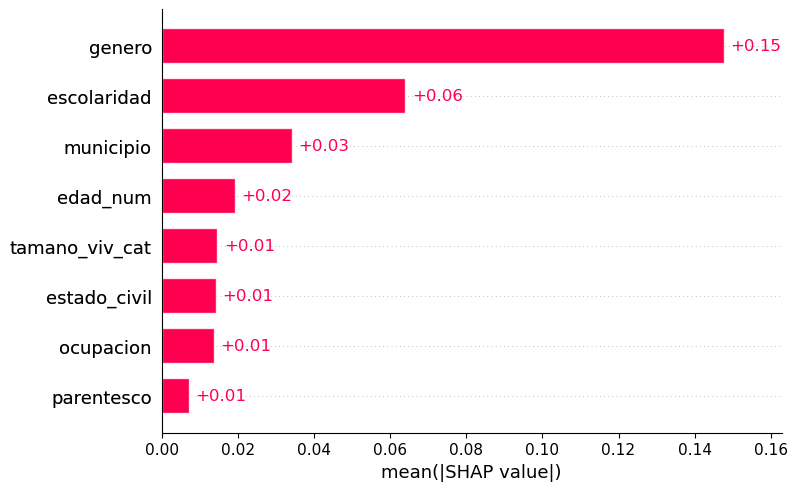

In [50]:
shap.plots.bar(exp2)